In [62]:
#ignore warnings
import warnings
warnings.filterwarnings('ignore')

#standard Libraries
import pandas as pd
import numpy as np

#visualization
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (10,8)

from collections import Counter

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn import metrics

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [2]:
train = pd.read_csv('test.csv')
test = pd.read_csv('train.csv')

In [3]:
#see what is present in the data
train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,...,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978,2,STANDING
1,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,-0.894088,...,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898,2,STANDING
2,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,-0.939260,...,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346,2,STANDING
3,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,-0.968897,-0.938610,...,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108,2,STANDING
4,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,-0.977346,-0.938610,...,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857,2,STANDING


In [4]:
#see what is present in the data
train.tail()


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
2942,0.310155,-0.053391,-0.099109,-0.287866,-0.140589,-0.215088,-0.356083,-0.148775,-0.232057,0.185361,...,-0.750809,-0.337422,0.346295,0.884904,-0.698885,-0.651732,0.274627,0.184784,24,WALKING_UPSTAIRS
2943,0.363385,-0.039214,-0.105915,-0.305388,0.028148,-0.196373,-0.373540,-0.030036,-0.270237,0.185361,...,-0.700274,-0.736701,-0.372889,-0.657421,0.322549,-0.655181,0.273578,0.182412,24,WALKING_UPSTAIRS
2944,0.349966,0.030077,-0.115788,-0.329638,-0.042143,-0.250181,-0.388017,-0.133257,-0.347029,0.007471,...,-0.467179,-0.181560,0.088574,0.696663,0.363139,-0.655357,0.274479,0.181184,24,WALKING_UPSTAIRS
2945,0.237594,0.018467,-0.096499,-0.323114,-0.229775,-0.207574,-0.392380,-0.279610,-0.289477,0.007471,...,-0.617737,0.444558,-0.819188,0.929294,-0.008398,-0.659719,0.264782,0.187563,24,WALKING_UPSTAIRS
2946,0.153627,-0.018437,-0.137018,-0.330046,-0.195253,-0.164339,-0.430974,-0.218295,-0.229933,-0.111527,...,-0.436940,0.598808,-0.287951,0.876030,-0.024965,-0.660080,0.263936,0.188103,24,WALKING_UPSTAIRS


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2947 entries, 0 to 2946
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), object(1)
memory usage: 12.7+ MB


In [8]:
train.shape

(2947, 563)

In [7]:
train.describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject
count,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,...,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000
mean,0.273996,-0.017863,-0.108386,-0.613635,-0.508330,-0.633797,-0.641278,-0.522676,-0.637038,-0.462063,...,-0.277593,-0.598756,0.005264,0.003799,0.040029,-0.017298,-0.513923,0.074886,-0.048720,12.986427
std,0.060570,0.025745,0.042747,0.412597,0.494269,0.362699,0.385199,0.479899,0.357753,0.523916,...,0.317245,0.311042,0.336147,0.445077,0.634989,0.501311,0.509205,0.324300,0.241467,6.950984
min,-0.592004,-0.362884,-0.576184,-0.999606,-1.000000,-0.998955,-0.999417,-0.999914,-0.998899,-0.952357,...,-1.000000,-1.000000,-1.000000,-0.993402,-0.998898,-0.991096,-0.984195,-0.913704,-0.949228,2.000000
25%,0.262075,-0.024961,-0.121162,-0.990914,-0.973664,-0.976122,-0.992333,-0.974131,-0.975352,-0.934447,...,-0.517494,-0.829593,-0.130541,-0.282600,-0.518924,-0.428375,-0.829722,0.022140,-0.098485,9.000000
50%,0.277113,-0.016967,-0.108458,-0.931214,-0.790972,-0.827534,-0.937664,-0.799907,-0.817005,-0.852659,...,-0.311023,-0.683672,0.005188,0.006767,0.047113,-0.026726,-0.729648,0.181563,-0.010671,12.000000
75%,0.288097,-0.010143,-0.097123,-0.267395,-0.105919,-0.311432,-0.321719,-0.133488,-0.322771,-0.009965,...,-0.083559,-0.458332,0.146200,0.288113,0.622151,0.394387,-0.545939,0.260252,0.092373,18.000000
max,0.671887,0.246106,0.494114,0.465299,1.000000,0.489703,0.439657,1.000000,0.427958,0.786436,...,1.000000,1.000000,0.998898,0.986347,1.000000,1.000000,0.833180,1.000000,0.973113,24.000000


In [9]:
train.dtypes

tBodyAcc-mean()-X       float64
tBodyAcc-mean()-Y       float64
tBodyAcc-mean()-Z       float64
tBodyAcc-std()-X        float64
tBodyAcc-std()-Y        float64
                         ...   
angle(X,gravityMean)    float64
angle(Y,gravityMean)    float64
angle(Z,gravityMean)    float64
subject                   int64
Activity                 object
Length: 563, dtype: object

In [10]:
# how many records are available for each subjects
train.subject.value_counts()

24    381
18    364
20    354
13    327
12    320
4     317
2     302
10    294
9     288
Name: subject, dtype: int64

In [11]:
#count how many unique value every feature have
train.nunique()

tBodyAcc-mean()-X       2947
tBodyAcc-mean()-Y       2947
tBodyAcc-mean()-Z       2947
tBodyAcc-std()-X        2947
tBodyAcc-std()-Y        2947
                        ... 
angle(X,gravityMean)    2947
angle(Y,gravityMean)    2947
angle(Z,gravityMean)    2947
subject                    9
Activity                   6
Length: 563, dtype: int64

In [12]:
train['Activity'].unique()

array(['STANDING', 'SITTING', 'LAYING', 'WALKING', 'WALKING_DOWNSTAIRS',
       'WALKING_UPSTAIRS'], dtype=object)

In [13]:
print('Number of duplicates in train : ',sum(train.duplicated()))
print('Number of duplicates in test  : ',sum(test.duplicated()))

Number of duplicates in train :  0
Number of duplicates in test  :  0


In [14]:
print('Number of Missing values in train : ',train.isna().values.sum())
print('Number of Missing values in test  : ',test.isna().values.sum())

Number of Missing values in train :  0
Number of Missing values in test  :  0


In [15]:
train.isnull().sum()

tBodyAcc-mean()-X       0
tBodyAcc-mean()-Y       0
tBodyAcc-mean()-Z       0
tBodyAcc-std()-X        0
tBodyAcc-std()-Y        0
                       ..
angle(X,gravityMean)    0
angle(Y,gravityMean)    0
angle(Z,gravityMean)    0
subject                 0
Activity                0
Length: 563, dtype: int64

In [16]:
train['Activity'].value_counts()

LAYING                537
STANDING              532
WALKING               496
SITTING               491
WALKING_UPSTAIRS      471
WALKING_DOWNSTAIRS    420
Name: Activity, dtype: int64

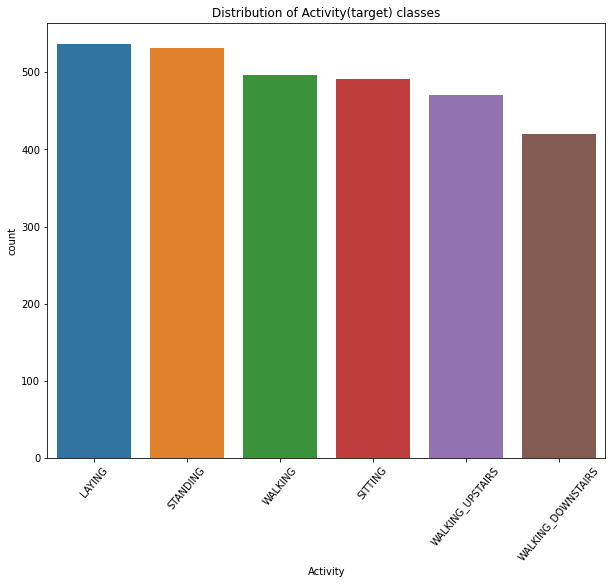

In [17]:
sns.countplot(x=train['Activity'],data=train,order =train['Activity'].value_counts().index)
plt.title('Distribution of Activity(target) classes')
plt.xticks(rotation=50)
plt.show()

In [18]:
train.columns

Index(['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z',
       'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z',
       'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z',
       'tBodyAcc-max()-X',
       ...
       'fBodyBodyGyroJerkMag-kurtosis()', 'angle(tBodyAccMean,gravity)',
       'angle(tBodyAccJerkMean),gravityMean)',
       'angle(tBodyGyroMean,gravityMean)',
       'angle(tBodyGyroJerkMean,gravityMean)', 'angle(X,gravityMean)',
       'angle(Y,gravityMean)', 'angle(Z,gravityMean)', 'subject', 'Activity'],
      dtype='object', length=563)

In [20]:
#assigning label encoder
le = LabelEncoder()
#label encoding target class "Activity"
train[['Activity']]= train[['Activity']].apply(le.fit_transform)

In [21]:
print(train.shape)
train.head(10)

(2947, 563)


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,...,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978,2,2
1,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,-0.894088,...,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898,2,2
2,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,-0.939260,...,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346,2,2
3,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,-0.968897,-0.938610,...,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108,2,2
4,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,-0.977346,-0.938610,...,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857,2,2
5,0.279220,-0.018620,-0.113902,-0.994455,-0.970417,-0.965316,-0.994585,-0.969481,-0.965897,-0.937856,...,-0.857565,-0.095681,0.048849,0.760684,-0.072216,-0.689816,0.294896,-0.068471,2,2
6,0.279746,-0.018271,-0.104000,-0.995819,-0.976354,-0.977725,-0.995996,-0.973665,-0.979253,-0.937856,...,-0.391286,-0.309083,-0.000857,0.728514,-0.333771,-0.690085,0.295282,-0.067065,2,2
7,0.274601,-0.025035,-0.116831,-0.995594,-0.982069,-0.985262,-0.995341,-0.981485,-0.984610,-0.941263,...,-0.672358,-0.025526,-0.214033,0.437640,-0.366674,-0.688785,0.295981,-0.067706,2,2
8,0.272529,-0.020954,-0.114472,-0.996784,-0.975906,-0.986597,-0.997029,-0.973735,-0.985556,-0.941263,...,-0.853248,0.144626,-0.035564,-0.181800,0.087320,-0.685390,0.299394,-0.065491,2,2
9,0.275746,-0.010372,-0.099776,-0.998373,-0.986933,-0.991022,-0.998663,-0.987140,-0.991084,-0.943761,...,-0.741435,0.157584,-0.033487,-0.350893,0.343146,-0.684110,0.300822,-0.064263,2,2


In [22]:
train.tail(20)

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
2927,0.206988,0.024602,-0.103940,-0.364650,-0.169378,-0.215814,-0.449295,-0.185957,-0.326199,-0.175652,...,-0.734494,0.535018,-0.256868,0.927325,-0.084328,-0.657011,0.266990,0.187901,24,5
2928,0.392804,-0.017788,-0.090166,-0.096349,-0.174368,-0.256686,-0.152987,-0.207809,-0.265253,0.485680,...,-0.036768,-0.742630,-0.080227,0.927331,-0.652179,-0.807271,0.189885,0.118456,24,4
2929,0.301162,-0.030034,-0.120333,-0.056181,-0.151753,-0.254848,-0.093334,-0.206796,-0.275332,0.485680,...,0.204816,-0.464962,0.291873,0.921466,-0.869951,-0.814760,0.190418,0.110325,24,4
2930,0.288214,0.011493,-0.155453,-0.063550,-0.035160,-0.230059,-0.093119,-0.116987,-0.258696,0.160374,...,-0.299539,-0.057336,-0.592802,0.964828,0.606231,-0.809277,0.192232,0.113997,24,4
2931,0.114866,-0.000427,-0.116904,-0.189544,0.078012,-0.312489,-0.268158,-0.047632,-0.341972,0.160374,...,-0.564841,0.849907,-0.643277,0.973227,0.062755,-0.809257,0.185954,0.120358,24,4
2932,0.126970,-0.013276,-0.073441,-0.173816,0.041540,-0.342513,-0.253156,-0.093578,-0.350155,0.285773,...,-0.252670,0.872466,0.491872,-0.155724,-0.762511,-0.800932,0.190968,0.123600,24,4
2933,0.363943,-0.022212,-0.125437,-0.041180,0.020777,-0.243607,-0.113519,-0.120400,-0.221709,0.411506,...,-0.205856,-0.895624,0.648047,-0.624180,-0.441569,-0.803888,0.191732,0.119944,24,4
2934,0.331044,-0.063979,-0.117333,-0.068002,0.156431,-0.317060,-0.148922,0.070107,-0.290868,0.411506,...,-0.468001,-0.351287,-0.335934,0.966914,-0.715323,-0.810091,0.184712,0.120724,24,4
2935,0.272259,-0.007579,-0.072642,-0.072559,0.005472,-0.225400,-0.161118,-0.074187,-0.280956,0.402615,...,-0.408741,0.181631,0.491898,-0.977969,-0.124243,-0.797719,0.194819,0.122937,24,4
2936,0.277271,0.001084,-0.074001,-0.068523,-0.245059,-0.144552,-0.148731,-0.303187,-0.198912,0.402615,...,-0.125531,0.133749,0.882511,-0.994293,0.475236,-0.803914,0.196823,0.114498,24,4


In [23]:
train.head()


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,...,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978,2,2
1,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,-0.894088,...,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898,2,2
2,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,-0.939260,...,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346,2,2
3,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,-0.968897,-0.938610,...,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108,2,2
4,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,-0.977346,-0.938610,...,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857,2,2


In [24]:
#Counting how much parameter does each feature has
pd.DataFrame.from_dict(Counter([col.split('-')[0].split('(')[0]
                                for col in train.columns]),orient = 'index').rename(columns={0:'count'}).sort_values('count',ascending = False)

,count
fBodyAcc,79
fBodyGyro,79
fBodyAccJerk,79
tGravityAcc,40
tBodyAcc,40
tBodyGyroJerk,40
tBodyGyro,40
tBodyAccJerk,40
tBodyAccMag,13
tGravityAccMag,13


Text(0.1, 9, 'Dynamic Activities')

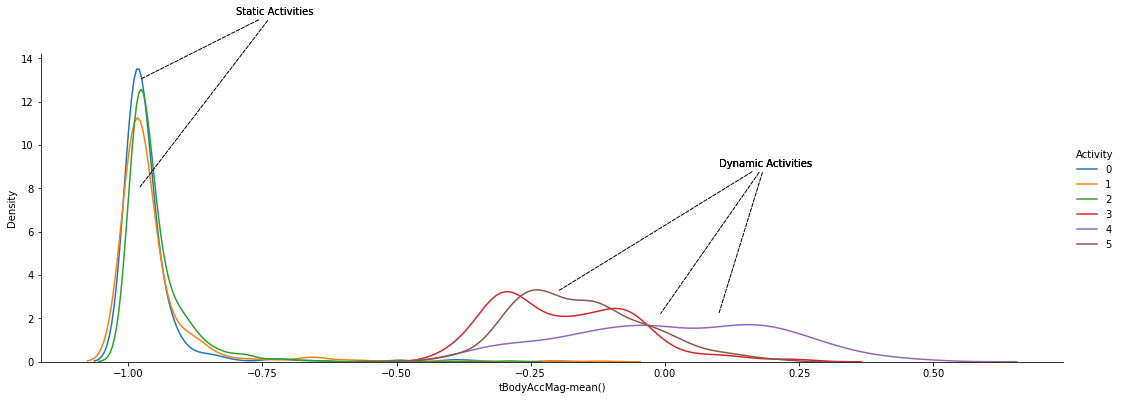

In [25]:
facetGrid = sns.FacetGrid(train,hue='Activity',height=5,aspect=3)
facetGrid.map(sns.distplot,'tBodyAccMag-mean()',hist = False).add_legend()

plt.annotate("Static Activities", xy = (-.98, 8), xytext = (-.8, 16), arrowprops={'arrowstyle': '-', 'ls': 'dashed'})
plt.annotate("Static Activities", xy = (-.98, 13), xytext = (-.8, 16), arrowprops={'arrowstyle': '-', 'ls': 'dashed'})
plt.annotate("Static Activities", xy = (-.98, 16), xytext = (-.8, 16), arrowprops={'arrowstyle': '-', 'ls': 'dashed'})

plt.annotate("Dynamic Activities", xy=(-0.2,3.25), xytext=(0.1, 9),arrowprops={'arrowstyle': '-', 'ls': 'dashed'})
plt.annotate("Dynamic Activities", xy=(0.1,2.18), xytext=(0.1, 9),arrowprops={'arrowstyle': '-', 'ls': 'dashed'})
plt.annotate("Dynamic Activities", xy=(-0.01,2.15), xytext=(0.1, 9),arrowprops={'arrowstyle': '-', 'ls': 'dashed'})

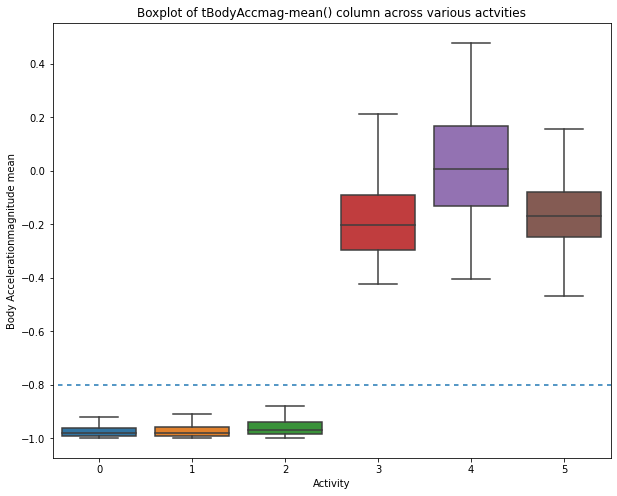

In [26]:
sns.boxplot(x='Activity',y='tBodyAccMag-mean()',data=train, showfliers=False)
plt.ylabel("Body Accelerationmagnitude mean")
plt.title('Boxplot of tBodyAccmag-mean() column across various actvities')
plt.axhline(y=-0.8,xmin=0.01,dashes=(3,3))
plt.show()

In [27]:
#Splitting the dataset
y = train['Activity']
X = train.drop(['Activity'], axis = 'columns')         #test data (removing target column)

In [28]:
y.head(10)

0    2
1    2
2    2
3    2
4    2
5    2
6    2
7    2
8    2
9    2
Name: Activity, dtype: int64

In [29]:
X.head(10)

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject
0,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,...,-0.330370,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978,2
1,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,-0.894088,...,-0.121845,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898,2
2,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,-0.939260,...,-0.190422,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346,2
3,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,-0.968897,-0.938610,...,-0.344418,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108,2
4,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,-0.977346,-0.938610,...,-0.534685,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857,2
5,0.279220,-0.018620,-0.113902,-0.994455,-0.970417,-0.965316,-0.994585,-0.969481,-0.965897,-0.937856,...,-0.493517,-0.857565,-0.095681,0.048849,0.760684,-0.072216,-0.689816,0.294896,-0.068471,2
6,0.279746,-0.018271,-0.104000,-0.995819,-0.976354,-0.977725,-0.995996,-0.973665,-0.979253,-0.937856,...,-0.093855,-0.391286,-0.309083,-0.000857,0.728514,-0.333771,-0.690085,0.295282,-0.067065,2
7,0.274601,-0.025035,-0.116831,-0.995594,-0.982069,-0.985262,-0.995341,-0.981485,-0.984610,-0.941263,...,-0.338123,-0.672358,-0.025526,-0.214033,0.437640,-0.366674,-0.688785,0.295981,-0.067706,2
8,0.272529,-0.020954,-0.114472,-0.996784,-0.975906,-0.986597,-0.997029,-0.973735,-0.985556,-0.941263,...,-0.629599,-0.853248,0.144626,-0.035564,-0.181800,0.087320,-0.685390,0.299394,-0.065491,2
9,0.275746,-0.010372,-0.099776,-0.998373,-0.986933,-0.991022,-0.998663,-0.987140,-0.991084,-0.943761,...,-0.469743,-0.741435,0.157584,-0.033487,-0.350893,0.343146,-0.684110,0.300822,-0.064263,2


In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 20, stratify = y)

In [32]:
print(X_train.shape)
print(X_test.shape)

(2357, 562)
(590, 562)


In [33]:
train.columns

Index(['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z',
       'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z',
       'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z',
       'tBodyAcc-max()-X',
       ...
       'fBodyBodyGyroJerkMag-kurtosis()', 'angle(tBodyAccMean,gravity)',
       'angle(tBodyAccJerkMean),gravityMean)',
       'angle(tBodyGyroMean,gravityMean)',
       'angle(tBodyGyroJerkMean,gravityMean)', 'angle(X,gravityMean)',
       'angle(Y,gravityMean)', 'angle(Z,gravityMean)', 'subject', 'Activity'],
      dtype='object', length=563)

In [34]:
X_train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject
1812,0.299933,-0.039028,-0.177081,0.084275,0.010410,-0.360834,0.047123,-0.010230,-0.397086,0.478241,...,-0.012820,-0.451091,-0.125223,-0.283798,0.867595,0.300771,-0.817406,0.218267,-0.022360,13
1656,0.334961,-0.042251,-0.067205,0.006344,-0.133133,-0.016360,-0.035416,-0.150856,-0.083309,0.206450,...,-0.388207,-0.776247,-0.331867,-0.874489,0.842206,-0.542224,-0.716758,0.233515,0.163636,13
1074,0.274905,-0.014076,-0.110867,-0.997158,-0.975103,-0.972583,-0.997531,-0.972196,-0.968548,-0.943546,...,-0.499559,-0.830618,0.087936,0.586501,-0.908241,0.786481,-0.811879,-0.035605,0.017415,10
2370,0.244885,-0.038492,-0.106697,-0.003722,0.344080,-0.171064,-0.056077,0.328639,-0.155305,0.387682,...,-0.028233,-0.379148,0.082549,0.832754,-0.939574,0.318706,-0.492242,0.385739,0.214768,20
2546,0.121554,-0.005661,-0.076260,-0.062792,0.353278,-0.218462,-0.163828,0.435934,-0.241550,0.487900,...,-0.522346,-0.852946,0.735238,-0.338768,-0.187114,-0.235846,-0.543148,0.412702,-0.006420,20


In [35]:
scaler = MinMaxScaler().fit(X_train)

In [38]:
print(scaler)

MinMaxScaler()


In [37]:
scaler.data_min_

array([-0.59200434, -0.3628841 , -0.57618401, -0.99960647, -1.        ,
       -0.99895457, -0.99937488, -0.999914  , -0.99871835, -0.95070817,
       -0.58348718, -0.84611421, -0.50681593, -0.88078226, -0.64868043,
       -0.99896692, -0.99999875, -1.        , -0.99999188, -0.99933933,
       -0.99976162, -0.99817382, -1.        , -1.        , -1.        ,
       -1.        , -1.        , -0.98351035, -1.        , -0.82812972,
       -0.6040749 , -0.65881439, -0.89526116, -0.81774415, -0.77567997,
       -0.95376571, -0.94613548, -0.98763255, -0.97734528, -1.        ,
       -0.80691286, -1.        , -0.99108979, -0.99995586, -1.        ,
       -0.99958348, -0.99994917, -1.        , -0.99968795, -0.86322538,
       -0.9999867 , -0.99047329, -0.7567742 , -1.        , -0.99111803,
       -0.90127699, -0.99999481, -0.99999778, -1.        , -0.99994923,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -0.99547916, -0.57605949, -0.99835285, -0.56666565, -0.99

In [39]:
scaler.data_max_

array([ 6.7188749e-01,  2.4610584e-01,  4.9411433e-01,  4.6529881e-01,
        9.6346226e-01,  4.8970267e-01,  4.3965684e-01,  8.8384780e-01,
        4.2795775e-01,  7.8643615e-01,  6.7471101e-01,  3.8451623e-01,
        8.5491058e-01,  7.0762981e-01,  8.5354261e-01,  4.8513814e-01,
        7.4740648e-02, -2.6025003e-01, -1.3052426e-02,  4.9403592e-01,
        5.1704665e-01,  7.9488852e-01,  1.0000000e+00,  7.2476862e-01,
        9.1609335e-01,  7.2185013e-01,  1.0000000e+00,  9.0782401e-01,
        8.7910665e-01,  6.9411027e-01,  7.8036187e-01,  8.9356554e-01,
        7.2413139e-01,  9.2732402e-01,  8.4013016e-01,  1.0000000e+00,
        6.4169415e-01,  9.7215594e-01,  9.6684694e-01,  9.8521018e-01,
        1.0000000e+00,  9.8283092e-01,  9.9558775e-01,  5.4211655e-01,
       -1.3004536e-01,  2.9107265e-02,  5.2533394e-01, -1.1473544e-01,
        5.7080083e-02,  9.9078875e-01,  1.0000000e+00,  1.0000000e+00,
        9.9614843e-01,  9.9051728e-01,  9.8654864e-01,  9.4715063e-01,
      

In [40]:
X_train.describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject
count,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,...,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000
mean,0.273435,-0.018276,-0.108055,-0.613311,-0.511391,-0.634599,-0.641044,-0.525191,-0.637480,-0.461160,...,-0.281244,-0.601546,0.005846,-0.001007,0.042218,-0.020507,-0.515017,0.075032,-0.048190,13.026729
std,0.061860,0.025942,0.043127,0.412963,0.489879,0.361244,0.385405,0.476154,0.356768,0.524947,...,0.317615,0.310166,0.332715,0.446353,0.633694,0.501623,0.510111,0.323293,0.241969,6.971605
min,-0.592004,-0.362884,-0.576184,-0.999606,-1.000000,-0.998955,-0.999375,-0.999914,-0.998718,-0.950708,...,-1.000000,-1.000000,-0.977973,-0.993402,-0.998898,-0.991096,-0.984195,-0.913704,-0.949228,2.000000
25%,0.262389,-0.024892,-0.120690,-0.991049,-0.973857,-0.975950,-0.992425,-0.974177,-0.975221,-0.934487,...,-0.520095,-0.834131,-0.129984,-0.283074,-0.512883,-0.431686,-0.830457,0.024340,-0.098614,9.000000
50%,0.277218,-0.016978,-0.108248,-0.932172,-0.789002,-0.827534,-0.937419,-0.795071,-0.820125,-0.852378,...,-0.315179,-0.687216,0.004975,0.000892,0.047267,-0.028790,-0.732201,0.181298,-0.010852,12.000000
75%,0.288383,-0.010372,-0.096704,-0.268764,-0.111459,-0.312579,-0.325212,-0.138074,-0.323658,-0.002905,...,-0.086279,-0.461018,0.141747,0.287623,0.623934,0.380586,-0.546097,0.258235,0.093169,20.000000
max,0.671887,0.246106,0.494114,0.465299,0.963462,0.489703,0.439657,0.883848,0.427958,0.786436,...,1.000000,1.000000,0.957756,0.982788,1.000000,0.983979,0.833180,1.000000,0.973113,24.000000


In [41]:
scaler.feature_range

(0, 1)

In [42]:
scaler.transform(X_train)

array([[0.70570708, 0.53179191, 0.37288932, ..., 0.59150782, 0.48215586,
        0.5       ],
       [0.73342113, 0.5265003 , 0.47554904, ..., 0.59947563, 0.57891104,
        0.5       ],
       [0.68590496, 0.57276475, 0.43475415, ..., 0.45884792, 0.50284674,
        0.36363636],
       ...,
       [0.68779118, 0.56712161, 0.43881524, ..., 0.42669063, 0.44011653,
        1.        ],
       [0.69914094, 0.57129223, 0.38906943, ..., 0.54483122, 0.46151536,
        0.09090909],
       [0.68844035, 0.55286804, 0.43550794, ..., 0.43114873, 0.99548028,
        0.36363636]])

In [43]:
scaler = MinMaxScaler().fit(X_test)

In [44]:
print(scaler)

MinMaxScaler()


In [45]:
scaler.data_min_

array([-0.27033343, -0.12193899, -0.42723163, -0.99949307, -0.99807443,
       -0.99861825, -0.99941708, -0.99751643, -0.99889873, -0.95235713,
       -0.57866438, -0.84550954, -0.38034161, -0.86642271, -0.25874585,
       -0.99785921, -0.99999814, -0.99998756, -0.99998449, -0.99909483,
       -0.9986836 , -0.99762577, -1.        , -0.9333724 , -1.        ,
       -0.80960332, -0.55328331, -0.94166371, -0.59857176, -0.7122775 ,
       -0.53660034, -0.57185596, -0.89987032, -0.65210198, -1.        ,
       -0.76503531, -0.6390668 , -0.94509667, -0.96419978, -0.9284766 ,
       -0.79008892, -0.99961699, -0.99081786, -0.99969684, -0.99966899,
       -0.99925992, -0.99976559, -0.99969159, -0.99932989, -0.85021152,
       -1.        , -0.99073801, -0.73896161, -0.95915039, -0.98859671,
       -0.83799278, -0.99999224, -0.99996876, -0.99999605, -0.99995129,
       -0.99992283, -0.99932283, -1.        , -1.        , -1.        ,
       -0.9919957 , -0.34143074, -0.99461913, -0.12791907, -0.98

In [46]:
scaler.data_max_

array([ 4.6013352e-01,  1.5867295e-01,  3.1399056e-01,  4.5004675e-01,
        1.0000000e+00,  3.7999219e-01,  4.1996098e-01,  1.0000000e+00,
        3.8454484e-01,  6.8902898e-01,  6.7471101e-01,  3.8451623e-01,
        8.5403016e-01,  6.9774878e-01,  8.5427720e-01,  4.0022192e-01,
        5.5092662e-02, -2.3380276e-01, -5.0293346e-02,  4.2552876e-01,
        6.5663705e-01,  4.4930528e-01,  8.2215131e-01,  6.0527025e-01,
        7.0747029e-01,  8.0683073e-01,  7.7620630e-01,  6.3356082e-01,
        8.3022082e-01,  7.1931356e-01,  6.8460872e-01,  8.9691709e-01,
        6.9352503e-01,  1.0000000e+00,  6.4438816e-01,  7.2394112e-01,
        5.1270929e-01,  9.7855342e-01,  8.1470785e-01,  9.9440525e-01,
        9.9394624e-01,  9.7928448e-01,  9.7738340e-01,  2.2838746e-01,
       -1.1946833e-02,  5.6096027e-01,  1.9708155e-01, -7.1650299e-02,
        5.2432207e-01,  9.8574672e-01,  9.3780602e-01,  9.7798541e-01,
        9.9589742e-01,  9.9094646e-01,  9.7634513e-01,  9.5147576e-01,
      

In [47]:
scaler.feature_range

(0, 1)

In [48]:
scaler.transform(X_test)

array([[0.74252839, 0.35874323, 0.44061715, ..., 0.22851703, 0.20923567,
        0.        ],
       [0.75008979, 0.34991754, 0.41172258, ..., 0.57424637, 0.51600183,
        0.45454545],
       [0.68929672, 0.56490277, 0.44041886, ..., 0.69537141, 0.6144815 ,
        0.81818182],
       ...,
       [0.75534295, 0.36865664, 0.39695699, ..., 0.54794624, 0.44289368,
        0.09090909],
       [0.78124546, 0.23252367, 0.14761626, ..., 0.5789529 , 0.4781125 ,
        0.36363636],
       [0.75376088, 0.45607951, 0.40388302, ..., 0.62017247, 0.6559401 ,
        0.        ]])

In [51]:
# Initialize and train the logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)


# Predict on the test data
y_pred = model.predict(X_test)

In [52]:
# Evaluate the model
confusion_mat = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)


In [53]:
print("Confusion Matrix:")
print(confusion_mat)


Confusion Matrix:
[[108   0   0   0   0   0]
 [  0  97   1   0   0   0]
 [  0   4 103   0   0   0]
 [  0   0   0  99   0   0]
 [  0   0   0   0  84   0]
 [  0   0   0   0   0  94]]


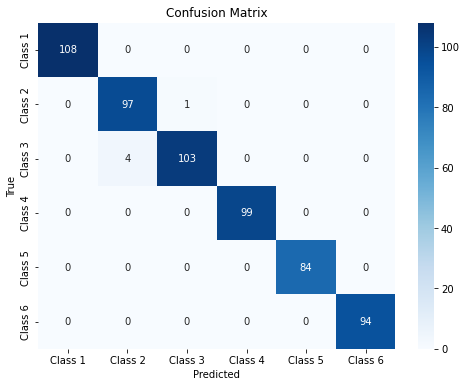

Classification Report:
               precision    recall  f1-score   support

     Class 1       1.00      1.00      1.00       108
     Class 2       0.96      0.99      0.97        98
     Class 3       0.99      0.96      0.98       107
     Class 4       1.00      1.00      1.00        99
     Class 5       1.00      1.00      1.00        84
     Class 6       1.00      1.00      1.00        94

    accuracy                           0.99       590
   macro avg       0.99      0.99      0.99       590
weighted avg       0.99      0.99      0.99       590



In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
confusion_mat = confusion_matrix(y_test, y_pred)

# Define class labels
class_names = ["Class 1", "Class 2", "Class 3", "Class 4", "Class 5", "Class 6"]

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Generate and display classification report
class_report = classification_report(y_test, y_pred, target_names=class_names)
print("Classification Report:\n", class_report)


In [61]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.9915254237288136


In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [64]:
svm_model = SVC(kernel='linear')

In [65]:
svm_model.fit(X_train, y_train)

SVC(kernel='linear')

In [66]:
y_pred = svm_model.predict(X_test)

In [67]:
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Classification Report:\n", report)

Accuracy: 0.9932203389830508
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       106
           1       0.99      0.97      0.98       103
           2       0.97      0.99      0.98        96
           3       1.00      1.00      1.00        97
           4       1.00      1.00      1.00        83
           5       1.00      1.00      1.00       105

    accuracy                           0.99       590
   macro avg       0.99      0.99      0.99       590
weighted avg       0.99      0.99      0.99       590

